# Analista de Marketing i Estratégia Comercial: 29/06/2026
Cuál es el precio medio de los alojamientos por tipo de alojamiento en cada ciudad?

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, to_hex
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display
from pathlib import Path

# Nombre de la columna de precio (contiene el símbolo €)
PRECIO = 'price_€'

# =====================================================================
#  PALETA: solo DOS azules corporativos + degradados entre ellos
# =====================================================================
NAVY  = '#173453'   # azul principal (oscuro)
ACERO = '#2E6B96'   # azul secundario

# Tintas neutras para textos, ejes y rejilla
TINTA, TINTA_SUAVE, EJES, REJILLA = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'

# Rampa continua construida a partir de los dos azules (oscuro -> claro).
# TODOS los colores de ciudades y tipos salen de este degradado: no se usa
# ningún otro color, solo distintos tonos de navy y acero.
_CMAP_AZUL = LinearSegmentedColormap.from_list(
    'stayspain_azules', ['#0f2436', NAVY, ACERO, '#6BA3CB', '#B4D2E7'])


def rampa_azul(n, t0=0.05, t1=0.90):
    """Devuelve n tonos del degradado navy -> acero -> claro."""
    if n == 1:
        return [NAVY]
    return [to_hex(_CMAP_AZUL(t)) for t in np.linspace(t0, t1, n)]


def paleta_por_valor(serie_grupo):
    """Asigna un tono FIJO a cada categoría según su precio medio
    (más oscuro = más caro). Devuelve un dict categoría -> color, de modo que
    cada ciudad o tipo mantiene SIEMPRE el mismo color en todo el documento."""
    orden = serie_grupo.sort_values(ascending=False).index
    return dict(zip(orden, rampa_azul(len(orden))))


# --- Estilo global y consistente para todos los gráficos ---
plt.rcParams.update({
    'figure.figsize': (11, 6), 'figure.dpi': 110, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlecolor': TINTA,
    'axes.labelcolor': TINTA_SUAVE, 'axes.edgecolor': EJES, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': REJILLA, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': TINTA_SUAVE, 'ytick.color': TINTA_SUAVE,
    'axes.axisbelow': True, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# --- Estilos base para las tablas ---
_ESTILOS_TABLA = [
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'),
                                      ('color', TINTA), ('text-align', 'left'), ('padding', '6px 2px')]},
    {'selector': 'th', 'props': [('background-color', '#f0efec'), ('color', TINTA),
                                 ('font-weight', '600'), ('text-align', 'center'), ('padding', '6px 10px')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('padding', '4px 10px')]},
]

# Dos tintes de AZUL similares para intercalar (zebra) en las tablas de tests
_ZEBRA_A, _ZEBRA_B = '#e4eef7', '#d2e2f0'


def tabla_estilo(datos, titulo='', gradiente='Blues'):
    """Styler con formato limpio (para tablas descriptivas). El degradado por
    defecto es azul ('Blues'), coherente con la paleta de dos azules."""
    df_ = datos.to_frame() if isinstance(datos, pd.Series) else datos.copy()
    sty = (df_.style
           .format(precision=2, thousands=',', na_rep='—')
           .set_caption(titulo)
           .set_table_styles(_ESTILOS_TABLA))
    num_cols = list(df_.select_dtypes('number').columns)
    if gradiente is not None and num_cols:
        sty = sty.background_gradient(cmap=gradiente, subset=num_cols)
    return sty


def tabla_anova(datos, titulo=''):
    """Styler para tablas de tests (ANOVA/Tukey): letra más oscura y filas
    intercaladas con dos tintes de azul similares para distinguir cada línea."""
    df_ = datos.copy().reset_index(drop=True)
    sty = (df_.style
           .format(precision=2, thousands=',', na_rep='—')
           .set_caption(titulo)
           .set_table_styles(_ESTILOS_TABLA + [
               {'selector': 'td', 'props': [('color', TINTA), ('font-weight', '600'),
                                            ('text-align', 'right'), ('padding', '4px 10px')]},
           ]))

    def _zebra(fila):
        color = _ZEBRA_A if fila.name % 2 == 0 else _ZEBRA_B
        return [f'background-color: {color}'] * len(fila)

    return sty.apply(_zebra, axis=1)


def tukey_a_df(datos, valor, grupo):
    """Ejecuta el test de Tukey HSD filtrando los nulos y devuelve el resultado como DataFrame."""
    d = datos.dropna(subset=[valor])
    t = pairwise_tukeyhsd(endog=d[valor], groups=d[grupo], alpha=0.05)
    return pd.DataFrame(t._results_table.data[1:], columns=t._results_table.data[0])

In [66]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Función para encontrar la carpeta raíz del proyecto subiendo desde el directorio actual.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}")

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_29_06_2026.csv'

print(f"Ruta resuelta: {ruta}")
df_original = pd.read_csv(ruta)
df = df_original.copy()

# Filtramos los nulos del precio una sola vez: 'df_precio' es la base limpia
# que usaremos en TODOS los análisis y tests estadísticos de este notebook.
n_nulos = df[PRECIO].isna().sum()
df_precio = df.dropna(subset=[PRECIO]).copy()

# Mapas de color FIJOS derivados del degradado de dos azules (navy y acero).
# Cada ciudad y cada tipo reciben un tono constante: así, si una ciudad tiene un
# color, será el mismo cada vez que aparezca en el documento.
COLOR_CIUDAD = paleta_por_valor(df_precio.groupby('city')[PRECIO].mean())
COLOR_TIPO = paleta_por_valor(df_precio.groupby('room_type')[PRECIO].mean())

print(f"Filas totales: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Nulos en {PRECIO}: {n_nulos} ({n_nulos / len(df):.1%})")
print(f"Filas válidas para el análisis de precios: {len(df_precio)}")

Ruta resuelta: e:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Data\clean_dataset_29_06_2026.csv
Filas totales: 6733 | Columnas: 18
Nulos en price_€: 121 (1.8%)
Filas válidas para el análisis de precios: 6612


### Desglose y preparación de la pregunta-resupuesta
Variables 
- price avg 
- room_type
- city 

Métricas (cálculo) 
- AVG agrupado por tipo y ciudad 

Análisis (tipo de herramienta o elemento estadístico) 
- MEDIA (ir haciendo zoom --> global --> ciudad --> tipo --> tipo y ciudad) 
- Test de diferencia de medias (comparativa puede ser anova o tuckey p ejemplo) 

Respuesta
- El precio medio por tipo de alojamiento y ciudad es X€. 
- Comparar y realizar una frase en diferencias de interés  

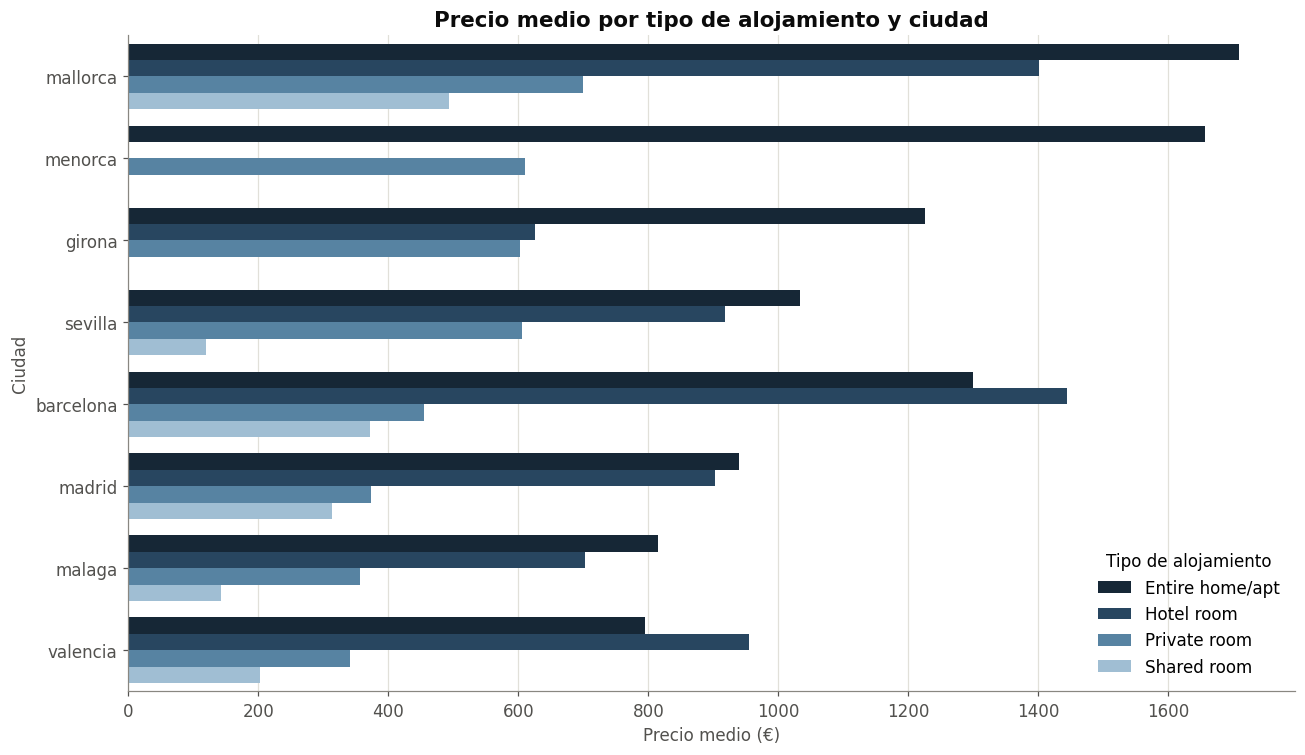

In [67]:
# Precio medio por tipo de alojamiento y ciudad -> barplot horizontal
# Eje Y = ciudad (ordenada de mayor a menor precio medio), barras por tipo de alojamiento.
orden_ciudad_precio = df_precio.groupby('city')[PRECIO].mean().sort_values(ascending=False).index
orden_tipo_precio = df_precio.groupby('room_type')[PRECIO].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=df_precio, y='city', x=PRECIO, hue='room_type',
            order=orden_ciudad_precio, hue_order=orden_tipo_precio,
            palette=COLOR_TIPO, estimator='mean', errorbar=None, ax=ax)
ax.set_title('Precio medio por tipo de alojamiento y ciudad')
ax.set_xlabel('Precio medio (€)')
ax.set_ylabel('Ciudad')
ax.legend(title='Tipo de alojamiento', frameon=False)
plt.tight_layout()
plt.show()

Precio promedio global

In [68]:
precio_medio_global = df_precio[PRECIO].mean().round(2)
print(f"Precio medio global: {precio_medio_global:,.2f} €")

Precio medio global: 1,009.36 €


Precio por ciudad

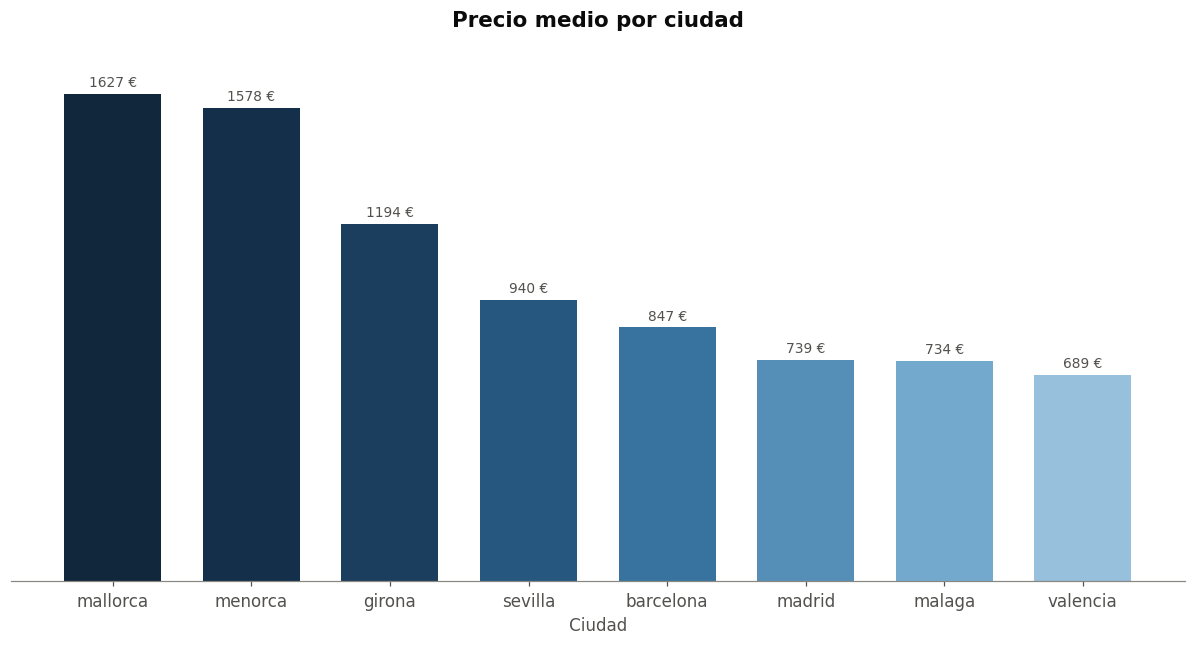

In [69]:
# Precio medio por ciudad (cada ciudad con su color corporativo fijo)
serie_ciudad = df_precio.groupby('city')[PRECIO].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
barras = ax.bar(serie_ciudad.index, serie_ciudad.values,
                color=[COLOR_CIUDAD[c] for c in serie_ciudad.index], width=0.7)
ax.bar_label(barras, fmt='%.0f €', padding=3, fontsize=9, color=TINTA_SUAVE)
ax.set_title('Precio medio por ciudad')
ax.set_xlabel('Ciudad')
ax.set_ylabel('')
ax.set_yticks([])                       # quitamos los números del eje Y
ax.spines['left'].set_visible(False)
ax.grid(False)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

ANOVA entre ciudades

In [70]:
print("=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES (Tukey HSD) ===")

# El test se ejecuta sobre los datos SIN nulos (la función 'tukey_a_df' aplica el dropna)
df_ciudades = tukey_a_df(df, PRECIO, 'city')

# Nos quedamos con las comparaciones significativas, ordenadas por diferencia de medias
significativas_ciudad = (
    df_ciudades[df_ciudades['reject']]
    .sort_values('meandiff', ascending=False)
    .reset_index(drop=True)
)

print(f"Comparaciones significativas: {len(significativas_ciudad)} de {len(df_ciudades)}")
tabla_anova(significativas_ciudad, 'Diferencias significativas de precio entre ciudades (Tukey HSD)')

=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES (Tukey HSD) ===
Comparaciones significativas: 22 de 28


,group1,group2,meandiff,p-adj,lower,upper,reject
0,malaga,mallorca,892.69,0.00,744.28,"1,041.10",True
1,madrid,mallorca,887.81,0.00,790.49,985.13,True
2,malaga,menorca,844.47,0.00,602.64,"1,086.30",True
3,madrid,menorca,839.59,0.00,625.28,"1,053.90",True
4,barcelona,mallorca,779.38,0.00,688.79,869.97,True
5,barcelona,menorca,731.16,0.00,519.82,942.49,True
6,girona,mallorca,433.03,0.00,329.75,536.31,True
7,girona,menorca,384.81,0.00,167.72,601.89,True
8,barcelona,girona,346.35,0.00,256.75,435.95,True
9,malaga,sevilla,206.27,0.01,24.18,388.36,True


Precio por tipo de alojamiento

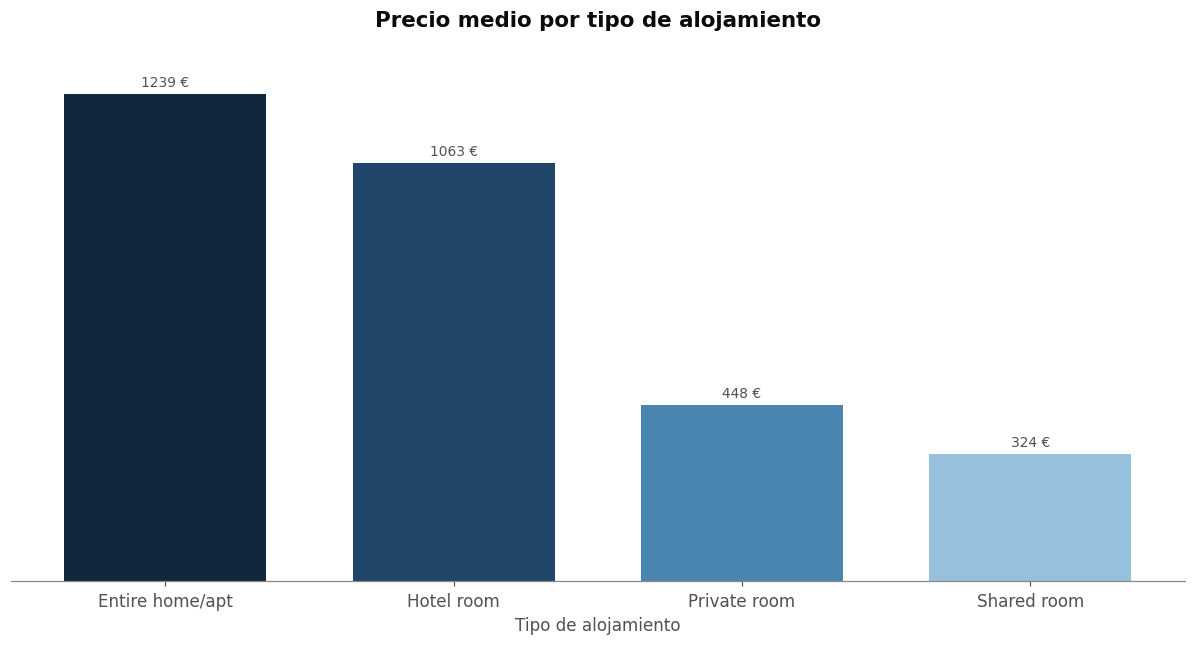

In [71]:
# Precio medio por tipo de alojamiento (mismos colores del logo que en el resto del documento)
serie_tipo = df_precio.groupby('room_type')[PRECIO].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
barras = ax.bar(serie_tipo.index, serie_tipo.values,
                color=[COLOR_TIPO[t] for t in serie_tipo.index], width=0.7)
ax.bar_label(barras, fmt='%.0f €', padding=3, fontsize=9, color=TINTA_SUAVE)
ax.set_title('Precio medio por tipo de alojamiento')
ax.set_xlabel('Tipo de alojamiento')
ax.set_ylabel('')
ax.set_yticks([])                       # quitamos los números del eje Y
ax.spines['left'].set_visible(False)
ax.grid(False)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

ANOVA entre tipo de alojamiento

In [72]:
print("=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO (Tukey HSD) ===")

# El test se ejecuta sobre los datos SIN nulos (la función 'tukey_a_df' aplica el dropna)
df_tipos = tukey_a_df(df, PRECIO, 'room_type')

tabla_anova(df_tipos, 'Comparación de precios entre tipos de alojamiento (Tukey HSD)')

=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO (Tukey HSD) ===


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-176.46,0.55,-519.67,166.75,False
1,Entire home/apt,Private room,-791.37,0.00,-845.15,-737.58,True
2,Entire home/apt,Shared room,-915.35,0.00,"-1,223.52",-607.18,True
3,Hotel room,Private room,-614.90,0.00,-959.91,-269.89,True
4,Hotel room,Shared room,-738.88,0.00,"-1,198.35",-279.42,True
5,Private room,Shared room,-123.98,0.73,-434.16,186.20,False


Crear la tabla agrupada (MultiIndex)

In [73]:
# Tabla ciudad × tipo de alojamiento (precio medio en €)
tabla_precio = (
    df_precio.pivot_table(values=PRECIO, index='city', columns='room_type', aggfunc='mean')
    .round(2)
)
tabla_estilo(tabla_precio, 'Precio medio (€): ciudad × tipo de alojamiento', gradiente='Blues')

room_type,Entire home/apt,Hotel room,Private room,Shared room
city,,,,
barcelona,"1,299.67","1,444.29",454.71,371.88
girona,"1,226.20",625.00,602.12,—
madrid,939.43,902.50,373.04,313.33
malaga,815.60,703.33,356.73,143.33
mallorca,"1,708.95","1,401.67",700.25,493.33
menorca,"1,656.53",—,610.00,—
sevilla,"1,033.60",918.57,606.00,120.00
valencia,794.57,955.00,340.77,203.33


 2. Graficar agrupando visualmente por el primer nivel (city)
.unstack() pasa 'room_type' a las columnas, creando el agrupamiento ideal para el gráfico

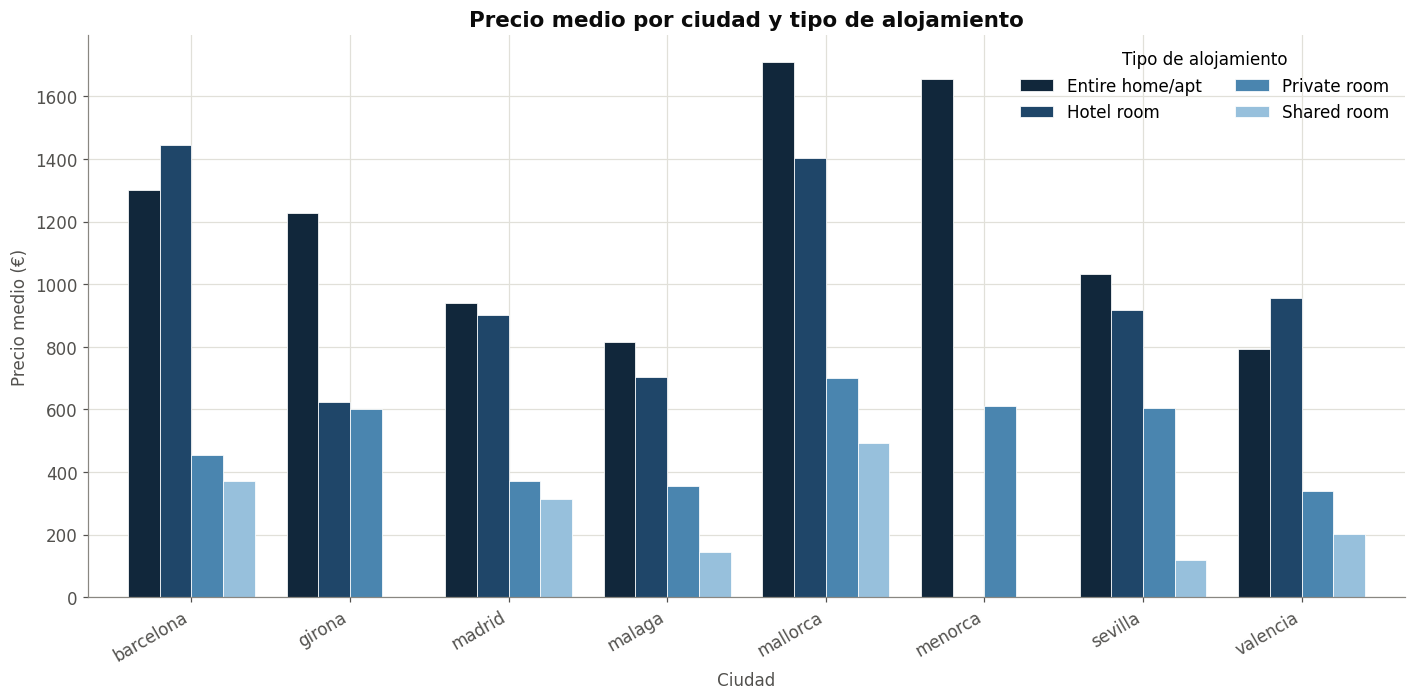

In [74]:
fig, ax = plt.subplots(figsize=(13, 6.5))
tabla_precio.plot(kind='bar', ax=ax, width=0.8,
                  color=[COLOR_TIPO[t] for t in tabla_precio.columns],
                  edgecolor='white', linewidth=0.5)

ax.set_title('Precio medio por ciudad y tipo de alojamiento')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Precio medio (€)')
ax.tick_params(axis='x', rotation=30)
for etiqueta in ax.get_xticklabels():
    etiqueta.set_ha('right')          # alinea las etiquetas rotadas para que se lean bien
ax.legend(title='Tipo de alojamiento', frameon=False, ncol=2)
plt.tight_layout()
plt.show()

POST- HOC Comparativa de alojamientos entre tipos en la misma ciudad

In [75]:
print("=== PARTE 1: COMPARACIÓN ENTRE TIPOS DE ALOJAMIENTO DENTRO DE CADA CIUDAD ===")

# Recorremos cada ciudad. 'tukey_a_df' filtra los nulos de precio antes del test,
# por eso las tablas ya NO salen con NaN.
for ciudad, sub_df in df.groupby('city'):
    resultado = tukey_a_df(sub_df, PRECIO, 'room_type')
    display(tabla_anova(resultado, f'{ciudad.capitalize()} — precio entre tipos de alojamiento'))

=== PARTE 1: COMPARACIÓN ENTRE TIPOS DE ALOJAMIENTO DENTRO DE CADA CIUDAD ===


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,144.62,0.93,-480.32,769.56,False
1,Entire home/apt,Private room,-844.95,0.00,-918.91,-770.99,True
2,Entire home/apt,Shared room,-927.79,0.00,"-1,343.13",-512.45,True
3,Hotel room,Private room,-989.57,0.00,"-1,614.22",-364.93,True
4,Hotel room,Shared room,"-1,072.41",0.00,"-1,818.88",-325.94,True
5,Private room,Shared room,-82.84,0.96,-497.74,332.06,False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-601.20,0.31,"-1,571.95",369.55,False
1,Entire home/apt,Private room,-624.09,0.00,-899.60,-348.58,True
2,Hotel room,Private room,-22.88,1.00,"-1,028.30",982.53,False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-36.93,1.00,-714.17,640.31,False
1,Entire home/apt,Private room,-566.39,0.00,-643.19,-489.59,True
2,Entire home/apt,Shared room,-626.10,0.00,-977.96,-274.23,True
3,Hotel room,Private room,-529.46,0.19,"-1,208.04",149.12,False
4,Hotel room,Shared room,-589.17,0.19,"-1,349.68",171.34,False
5,Private room,Shared room,-59.70,0.97,-414.13,294.72,False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-112.26,0.98,-878.25,653.73,False
1,Entire home/apt,Private room,-458.87,0.00,-653.67,-264.07,True
2,Entire home/apt,Shared room,-672.26,0.11,"-1,438.25",93.73,False
3,Hotel room,Private room,-346.61,0.66,"-1,128.98",435.77,False
4,Hotel room,Shared room,-560.00,0.54,"-1,637.45",517.45,False
5,Private room,Shared room,-213.39,0.90,-995.77,568.98,False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-307.29,0.87,"-1,329.97",715.39,False
1,Entire home/apt,Private room,"-1,008.70",0.00,"-1,301.14",-716.27,True
2,Entire home/apt,Shared room,"-1,215.62",0.13,"-2,659.63",228.39,False
3,Hotel room,Private room,-701.41,0.32,"-1,758.87",356.05,False
4,Hotel room,Shared room,-908.33,0.55,"-2,674.08",857.42,False
5,Private room,Shared room,-206.92,0.98,"-1,675.77","1,261.93",False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Private room,"-1,046.53",0.00,"-1,675.32",-417.74,True


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,-115.03,0.98,-927.89,697.83,False
1,Entire home/apt,Private room,-427.60,0.00,-713.27,-141.93,True
2,Entire home/apt,Shared room,-913.60,0.68,"-3,040.02","1,212.82",False
3,Hotel room,Private room,-312.57,0.77,"-1,153.90",528.76,False
4,Hotel room,Shared room,-798.57,0.80,"-3,067.47","1,470.33",False
5,Private room,Shared room,-486.00,0.94,"-2,623.47","1,651.47",False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Entire home/apt,Hotel room,160.43,0.98,-833.19,"1,154.05",False
1,Entire home/apt,Private room,-453.80,0.00,-650.90,-256.71,True
2,Entire home/apt,Shared room,-591.24,0.24,"-1,404.32",221.84,False
3,Hotel room,Private room,-614.23,0.39,"-1,618.55",390.09,False
4,Hotel room,Shared room,-751.67,0.43,"-2,028.74",525.41,False
5,Private room,Shared room,-137.44,0.97,-963.56,688.68,False


POST- HOC Comparativa de tipos de alojamientos entre ciudades

In [76]:
print("=== PARTE 2: COMPARACIÓN DEL MISMO TIPO DE ALOJAMIENTO ENTRE CIUDADES ===")

# Igual que antes: 'tukey_a_df' filtra los nulos, así que las tablas salen completas.
for alojamiento, sub_df in df.groupby('room_type'):
    resultado = tukey_a_df(sub_df, PRECIO, 'city')
    display(tabla_anova(resultado, f'{alojamiento} — precio entre ciudades'))

=== PARTE 2: COMPARACIÓN DEL MISMO TIPO DE ALOJAMIENTO ENTRE CIUDADES ===


,group1,group2,meandiff,p-adj,lower,upper,reject
0,barcelona,girona,-73.46,0.50,-186.04,39.11,False
1,barcelona,madrid,-360.24,0.00,-476.40,-244.07,True
2,barcelona,malaga,-484.07,0.00,-653.79,-314.36,True
3,barcelona,mallorca,409.29,0.00,294.83,523.75,True
4,barcelona,menorca,356.87,0.00,119.83,593.90,True
5,barcelona,sevilla,-266.07,0.00,-439.74,-92.39,True
6,barcelona,valencia,-505.10,0.00,-689.63,-320.56,True
7,girona,madrid,-286.77,0.00,-400.56,-172.99,True
8,girona,malaga,-410.61,0.00,-578.70,-242.51,True
9,girona,mallorca,482.75,0.00,370.71,594.80,True


,group1,group2,meandiff,p-adj,lower,upper,reject
0,barcelona,girona,-819.29,0.13,"-1,780.50",141.93,False
1,barcelona,madrid,-541.79,0.56,"-1,503.00",419.43,False
2,barcelona,malaga,-740.95,0.31,"-1,799.22",317.31,False
3,barcelona,mallorca,-42.62,1.00,-895.82,810.58,False
4,barcelona,sevilla,-525.71,0.41,"-1,345.44",294.02,False
5,barcelona,valencia,-489.29,0.86,"-1,718.88",740.31,False
6,girona,madrid,277.50,0.98,-806.90,"1,361.90",False
7,girona,malaga,78.33,1.00,"-1,092.95","1,249.62",False
8,girona,mallorca,776.67,0.20,-213.25,"1,766.58",False
9,girona,sevilla,293.57,0.96,-667.65,"1,254.79",False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,barcelona,girona,147.40,0.17,-26.25,321.05,False
1,barcelona,madrid,-81.68,0.01,-149.20,-14.15,True
2,barcelona,malaga,-97.99,0.65,-267.06,71.09,False
3,barcelona,mallorca,245.54,0.00,102.96,388.12,True
4,barcelona,menorca,155.29,0.93,-233.17,543.74,False
5,barcelona,sevilla,151.29,0.05,0.42,302.16,True
6,barcelona,valencia,-113.94,0.34,-270.16,42.28,False
7,girona,madrid,-229.08,0.00,-407.69,-50.47,True
8,girona,malaga,-245.39,0.04,-481.88,-8.90,True
9,girona,mallorca,98.14,0.87,-120.20,316.47,False


,group1,group2,meandiff,p-adj,lower,upper,reject
0,barcelona,madrid,-58.54,0.99,-353.80,236.71,False
1,barcelona,malaga,-228.54,0.77,-745.41,288.32,False
2,barcelona,mallorca,121.46,0.98,-395.41,638.32,False
3,barcelona,sevilla,-251.88,0.94,"-1,098.69",594.94,False
4,barcelona,valencia,-168.54,0.92,-685.41,348.32,False
5,madrid,malaga,-170.00,0.92,-689.58,349.58,False
6,madrid,mallorca,180.00,0.90,-339.58,699.58,False
7,madrid,sevilla,-193.33,0.98,"-1,041.80",655.14,False
8,madrid,valencia,-110.00,0.99,-629.58,409.58,False
9,malaga,mallorca,350.00,0.62,-320.77,"1,020.77",False


## Detección de outliers

Analizamos los valores atípicos (*outliers*) del **precio**, que es la variable central del estudio, de forma global y desglosada por **ciudad** y por **tipo de alojamiento**.

Usamos el **método del rango intercuartílico (IQR)**: se consideran outliers los valores por debajo de `Q1 − 1.5·IQR` o por encima de `Q3 + 1.5·IQR`. En los boxplots, los puntos que quedan fuera de los "bigotes" son precisamente esos valores atípicos.

Resumen de outliers del precio (global):
n             6612.00
Q1             450.00
Q3            1220.00
IQR            770.00
límite_inf    -705.00
límite_sup    2375.00
n_outliers     503.00
%_outliers       7.61


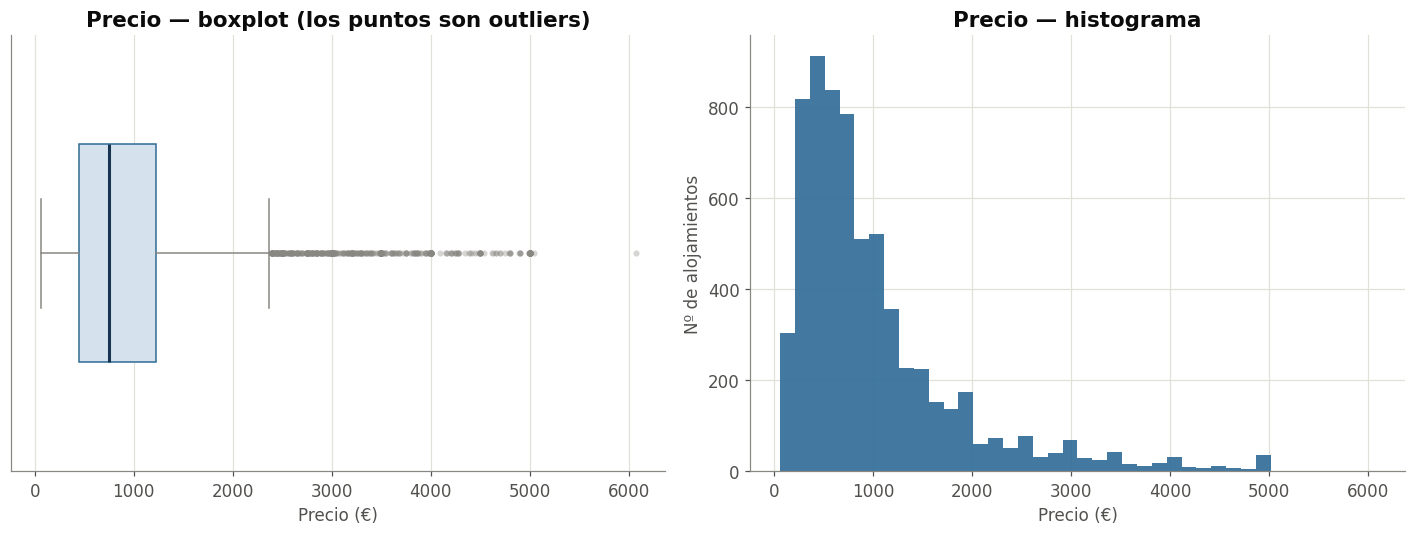

In [77]:
def resumen_outliers(serie):
    """Calcula los límites y el número de outliers de una serie con el método IQR."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = serie[(serie < lim_inf) | (serie > lim_sup)]
    return pd.Series({
        'n': int(serie.count()), 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'límite_inf': lim_inf, 'límite_sup': lim_sup,
        'n_outliers': int(atipicos.size),
        '%_outliers': round(100 * atipicos.size / serie.count(), 2),
    })

print("Resumen de outliers del precio (global):")
print(resumen_outliers(df_precio[PRECIO]).to_string())

# Boxplot + histograma del precio global (solo azules corporativos)
fig, (ax_box, ax_hist) = plt.subplots(1, 2, figsize=(13, 5))

ax_box.boxplot(df_precio[PRECIO], vert=False, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='#d5e2ee', color=ACERO),
               whiskerprops=dict(color=EJES), capprops=dict(color=EJES),
               medianprops=dict(color=NAVY, linewidth=2),
               flierprops=dict(marker='o', markersize=4, alpha=0.35,
                               markerfacecolor=EJES, markeredgecolor='none'))
ax_box.set_title('Precio — boxplot (los puntos son outliers)')
ax_box.set_xlabel('Precio (€)')
ax_box.set_yticks([])

ax_hist.hist(df_precio[PRECIO], bins=40, color=ACERO, alpha=0.9)
ax_hist.set_title('Precio — histograma')
ax_hist.set_xlabel('Precio (€)')
ax_hist.set_ylabel('Nº de alojamientos')

plt.tight_layout()
plt.show()

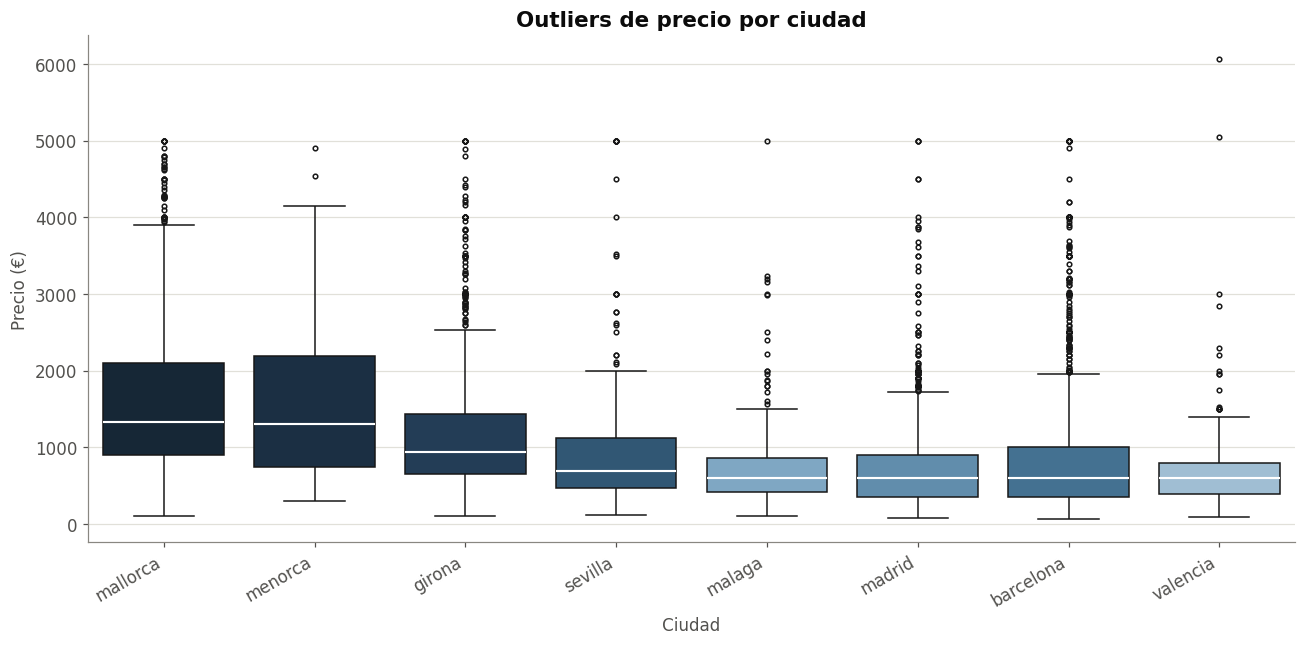

In [78]:
# Outliers de precio por CIUDAD (cada ciudad con el mismo tono azul que en el resto del documento)
orden_ciudad = df_precio.groupby('city')[PRECIO].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_precio, x='city', y=PRECIO, order=orden_ciudad,
            hue='city', legend=False, palette=COLOR_CIUDAD,
            fliersize=3, linewidth=1,
            medianprops=dict(color='white', linewidth=1.4), ax=ax)
ax.set_title('Outliers de precio por ciudad')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Precio (€)')
ax.tick_params(axis='x', rotation=30)
for etiqueta in ax.get_xticklabels():
    etiqueta.set_ha('right')
plt.tight_layout()
plt.show()

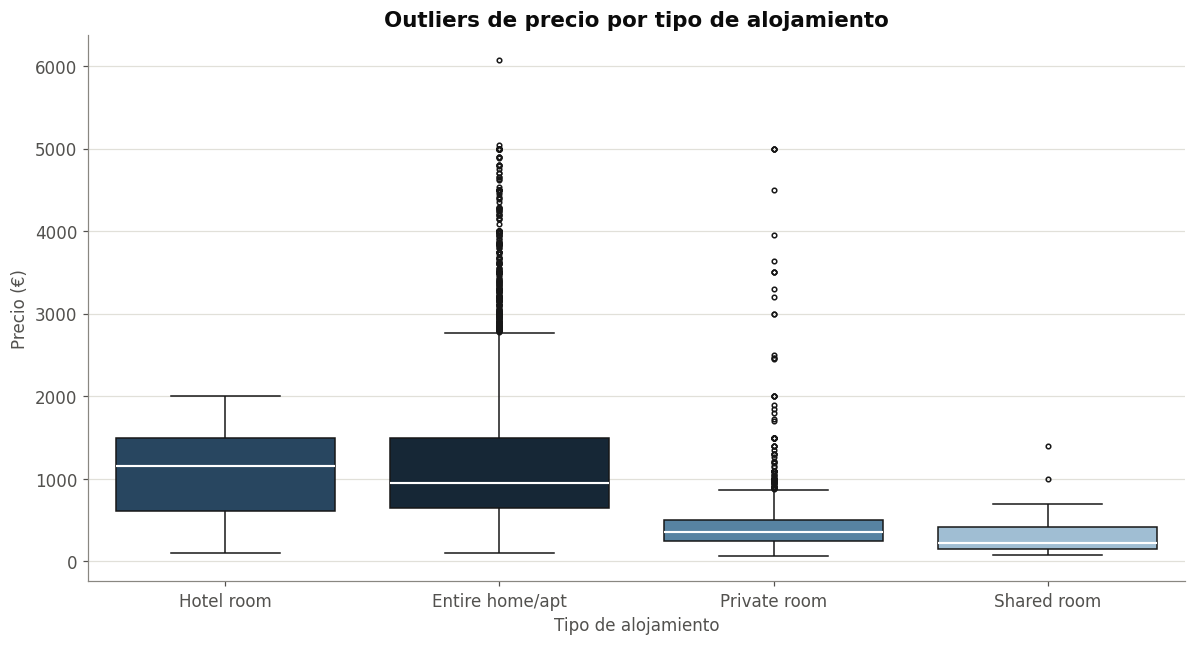

In [79]:
# Outliers de precio por TIPO DE ALOJAMIENTO (mismo tono azul que en el resto del documento)
orden_tipo = df_precio.groupby('room_type')[PRECIO].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df_precio, x='room_type', y=PRECIO, order=orden_tipo,
            hue='room_type', legend=False, palette=COLOR_TIPO,
            fliersize=3, linewidth=1,
            medianprops=dict(color='white', linewidth=1.4), ax=ax)
ax.set_title('Outliers de precio por tipo de alojamiento')
ax.set_xlabel('Tipo de alojamiento')
ax.set_ylabel('Precio (€)')
plt.tight_layout()
plt.show()

In [80]:
# Tabla resumen de outliers de precio por ciudad (ordenada por % de outliers)
resumen_outliers_ciudad = (
    df_precio.groupby('city')[PRECIO]
    .apply(resumen_outliers).unstack()
    .sort_values('%_outliers', ascending=False)
)
tabla_estilo(resumen_outliers_ciudad,
             'Resumen de outliers de precio por ciudad (método IQR)', gradiente='Blues')

,n,Q1,Q3,IQR,límite_inf,límite_sup,n_outliers,%_outliers
city,,,,,,,,
barcelona,"2,016.00",350.00,"1,000.00",650.00,-625.00,"1,975.00",146.00,7.24
girona,"1,070.00",650.00,"1,427.50",777.50,-516.25,"2,593.75",75.00,7.01
sevilla,339.00,475.00,"1,115.00",640.00,-485.00,"2,075.00",23.00,6.78
madrid,"1,386.00",350.00,900.00,550.00,-475.00,"1,725.00",82.00,5.92
malaga,338.00,412.50,865.00,452.50,-266.25,"1,543.75",19.00,5.62
valencia,294.00,390.00,800.00,410.00,-225.00,"1,415.00",15.00,5.10
mallorca,"1,035.00",900.00,"2,100.00","1,200.00",-900.00,"3,900.00",43.00,4.15
menorca,134.00,742.50,"2,195.00","1,452.50","-1,436.25","4,373.75",2.00,1.49
